# Etapa 1 & 2: ML Canvas + Exploração de Dados (EDA)
## Previsão de Churn - Telecomunicações

**Objetivo**: Entendimento de negócio (ML Canvas) + análise exploratória para identificar padrões de churn e qualidade dos dados.

**Dataset**: IBM Telco Customer Churn (public dataset)

## 1. ML Canvas: Contexto de Negócio e Proposta de Valor

### Problema de Negócio
Uma operadora de telecomunicações está perdendo clientes em ritmo acelerado, impactando a receita mensal (MRR).

### Proposta de Valor
Implementar um **sistema de alerta precoce** que identifique clientes com alta propensão ao cancelamento, permitindo que o time de Customer Success atue de forma personalizada.

### Atores de Negócio (Stakeholders)
- **Marketing**: Campanhas de retenção segmentadas
- **Financeiro**: Redução do impacto no MRR e aumento do LTV
- **Customer Success**: Ações de retenção personalizadas
- **Engenharia de ML**: Robustez, precisão e monitoramento do modelo

### KPIs de Sucesso

**Negócio:**
- Redução de 10% na taxa de churn trimestral
- Aumento de 15% no Lifetime Value (LTV) médio
- ROI de retenção > 400% (custo de retenção < 25% do revenue)

**Técnico:**
- F1-Score > 0.70 (importante devido ao desbalanceamento)
- AUC-ROC > 0.85 (boa discriminação)
- Recall ≥ 0.80 (capturar máximo de churn)
- Precision ≥ 0.65 (reduzir falsos positivos)
- Latência da API < 200ms

## 2. Importação de Bibliotecas e Configuração

In [35]:
# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import folium

warnings.filterwarnings('ignore')

# Configurações de visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 3. Carregamento do Dataset

In [36]:
# Carregar dataset Telco Customer Churn (IBM)
# Arquivo local em formato Excel

try:
    file_path = "../data/raw/Telco_customer_churn.xlsx"
    df = pd.read_excel(file_path)
    print(f"✅ Dataset carregado com sucesso!")
    print(f"Tamanho: {df.shape[0]} linhas × {df.shape[1]} colunas")
except FileNotFoundError:
    print(f"❌ Arquivo não encontrado em {file_path}")
    print("Caminho não encontrado. Verifique o local do arquivo.")
except Exception as e:
    print(f"❌ Erro ao carregar o arquivo: {e}")

# Exibir primeiras linhas
print("\n📊 Primeiras linhas do dataset:")
df.head()

✅ Dataset carregado com sucesso!
Tamanho: 7043 linhas × 33 colunas

📊 Primeiras linhas do dataset:


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 4. Inspeção Inicial dos Dados

In [37]:
# Informações gerais do dataset
print("=" * 80)
print("INFORMAÇÕES DO DATASET")
print("=" * 80)
print(f"\n📏 Dimensões: {df.shape[0]} registros × {df.shape[1]} attributes")
print(f"\n🔍 Tipos de dados:")
print(df.dtypes)

print(f"\n⚠️ Valores faltantes (missing values):")
missing = df.isnull().sum()

if missing.sum() == 0:
    print("✅ Nenhum valor faltante detectado!")    
else:    
    print(missing[missing > 0])

print(f"\n📊 Estatísticas descritivas (numéricas):")
df.describe()

INFORMAÇÕES DO DATASET

📏 Dimensões: 7043 registros × 33 attributes

🔍 Tipos de dados:
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV          

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


## 5. Avaliação de Qualidade de Dados

In [38]:
df["Total Charges"]

0        108.15
1        151.65
2         820.5
3       3046.05
4        5036.3
         ...   
7038     1419.4
7039     1990.5
7040     7362.9
7041     346.45
7042     6844.5
Name: Total Charges, Length: 7043, dtype: object

In [39]:
# Análise de valores especiais em coluna Total Charges
print("=" * 80)
print("ANÁLISE DE QUALIDADE: Coluna 'Total Charges'")
print("=" * 80)

total_charges_col = 'Total Charges'
tenure_col = 'Tenure Months'
churn_col = 'Churn Label'

# Verificar tipo de dados
print(f"\n📝 Tipo de dado atual: {df[total_charges_col].dtype}")

# Verificar valores únicos incomuns
print(f"\n🔍 Primeiros 10 valores únicos:")
print(df[total_charges_col].unique()[:10])

# Tenta converter para numérico; o 'errors=coerce' transforma o que não for número em NaN
non_numeric = df[pd.to_numeric(df[total_charges_col], errors='coerce').isnull()]

# Exibe apenas os valores únicos que estão causando o problema
print(f"⚠️ Valores não numéricos encontrados: {non_numeric[total_charges_col].unique()}")


# Verificar valores NaN antes conversão
print(f"\n📊 Valores NaN antes conversão: {df[total_charges_col].isnull().sum()}")

# Converter para float (tratando espaços em branco)
df[total_charges_col] = pd.to_numeric(df[total_charges_col], errors='coerce')

# Verificar valores NaN após conversão
print(f"\n📊 Valores NaN após conversão: {df[total_charges_col].isnull().sum()}")

# Verificar clientes novos (tenure = 0)
new_customers = df[df[tenure_col] == 0]
print(f"\n👥 Clientes novos (tenure=0): {len(new_customers)}")
print(f"   Desses, com Total Charges NaN: {new_customers[total_charges_col].isnull().sum()}")

# Preencher NaN com 0 (clientes novos ainda não geraram cobranças)
df[total_charges_col].fillna(0, inplace=True)

print(f"\n✅ Total Charges tratado com sucesso!")
print(f"   Tipo de dado agora: {df[total_charges_col].dtype}")
print(f"   Valores NaN restantes: {df[total_charges_col].isnull().sum()}")

ANÁLISE DE QUALIDADE: Coluna 'Total Charges'

📝 Tipo de dado atual: object

🔍 Primeiros 10 valores únicos:
[108.15 151.65 820.5 3046.05 5036.3 528.35 39.65 20.15 4749.15 30.2]
⚠️ Valores não numéricos encontrados: [' ']

📊 Valores NaN antes conversão: 0

📊 Valores NaN após conversão: 11

👥 Clientes novos (tenure=0): 11
   Desses, com Total Charges NaN: 11

✅ Total Charges tratado com sucesso!
   Tipo de dado agora: float64
   Valores NaN restantes: 0


## 6. Análise de Padrões de Churn

In [40]:
# Tab. 1: Distribuição de Churn
print("=" * 80)
print("ANÁLISE DE PADRÕES DE CHURN")
print("=" * 80)

# Definir nomes das colunas
churn_col = 'Churn Label'
contract_col = 'Contract'
internet_col = 'Internet Service'
payment_col = 'Payment Method'

print("\n📊 1. Distribuição da Variável Target (Churn):")
churn_dist = df[churn_col].value_counts()
churn_pct = df[churn_col].value_counts(normalize=True) * 100

for status, count in churn_dist.items():
    pct = churn_pct[status]
    print(f"   {status}: {count:5d} clientes ({pct:5.1f}%)")

if 'Yes' in churn_dist.index and 'No' in churn_dist.index:
    print(f"\n   ⚠️ Desbalanceamento: {churn_pct['No']:.1f}% (Não-Churn) vs {churn_pct['Yes']:.1f}% (Churn)")
    print(f"   → Razão: 1:{churn_pct['No']/churn_pct['Yes']:.2f}")

# Tab. 2: Churn por Tipo de Contrato
print("\n" + "=" * 50)
print("2️⃣ CHURN POR TIPO DE CONTRATO:")
print("=" * 50)

contract_churn = pd.crosstab(df[contract_col], df[churn_col], normalize='index') * 100
print(contract_churn.round(2))

print("\n   🔑 Insight: Contratos 'Month-to-month' têm MUITO MAIS churn")

# Tab. 3: Churn por Tipo de Internet
print("\n" + "=" * 50)
print("3️⃣ CHURN POR TIPO DE SERVIÇO DE INTERNET:")
print("=" * 50)

internet_churn = pd.crosstab(df[internet_col], df[churn_col], normalize='index') * 100
print(internet_churn.round(2))

print("\n   🔑 Insight: Fibra Óptica tem MAIOR churn que DSL")

# Tab. 4: Churn por Método de Pagamento
print("\n" + "=" * 50)
print("4️⃣ CHURN POR MÉTODO DE PAGAMENTO:")
print("=" * 50)

payment_churn = pd.crosstab(df[payment_col], df[churn_col], normalize='index') * 100
print(payment_churn.round(2))

print("\n   🔑 Insight: 'Electronic check' correlacionado com ALTO churn")

ANÁLISE DE PADRÕES DE CHURN

📊 1. Distribuição da Variável Target (Churn):
   No:  5174 clientes ( 73.5%)
   Yes:  1869 clientes ( 26.5%)

   ⚠️ Desbalanceamento: 73.5% (Não-Churn) vs 26.5% (Churn)
   → Razão: 1:2.77

2️⃣ CHURN POR TIPO DE CONTRATO:
Churn Label        No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83

   🔑 Insight: Contratos 'Month-to-month' têm MUITO MAIS churn

3️⃣ CHURN POR TIPO DE SERVIÇO DE INTERNET:
Churn Label          No    Yes
Internet Service              
DSL               81.04  18.96
Fiber optic       58.11  41.89
No                92.60   7.40

   🔑 Insight: Fibra Óptica tem MAIOR churn que DSL

4️⃣ CHURN POR MÉTODO DE PAGAMENTO:
Churn Label                   No    Yes
Payment Method                         
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11

   🔑 Insight: 

## 7. Visualizações - Padrões de Churn

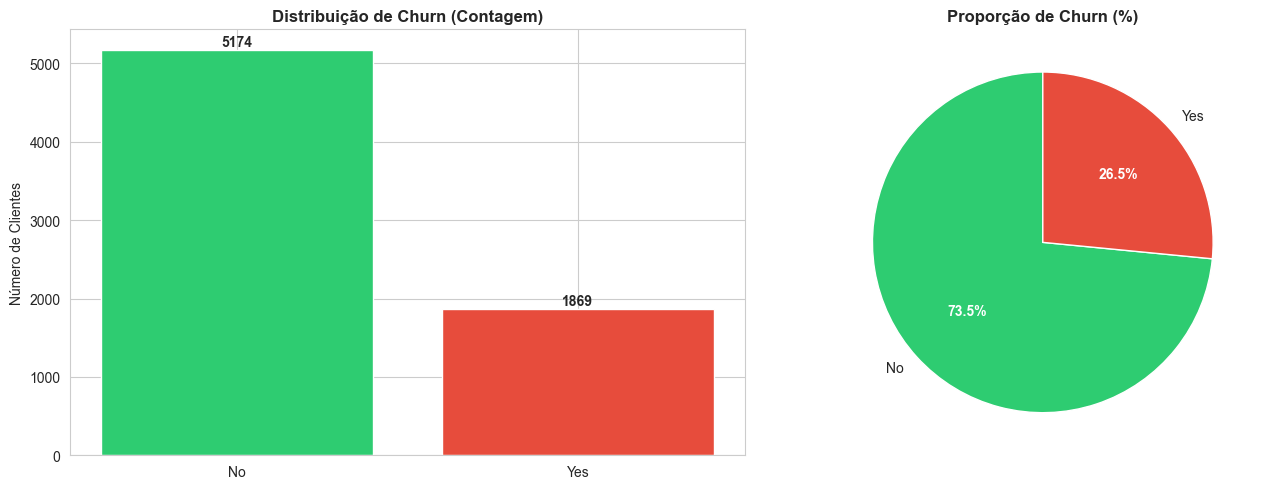

✅ Gráfico 1: Distribuição de Churn


In [42]:
# Figura 1: Distribuição de Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Contagem
churn_counts = df[churn_col].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribuição de Churn (Contagem)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de Clientes')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Gráfico 2: Proporção
churn_pct = df[churn_col].value_counts(normalize=True) * 100
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[1].pie(churn_pct.values, labels=churn_pct.index, autopct='%1.1f%%',
                                        colors=colors, startangle=90)
axes[1].set_title('Proporção de Churn (%)', fontsize=12, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

print("✅ Gráfico 1: Distribuição de Churn")

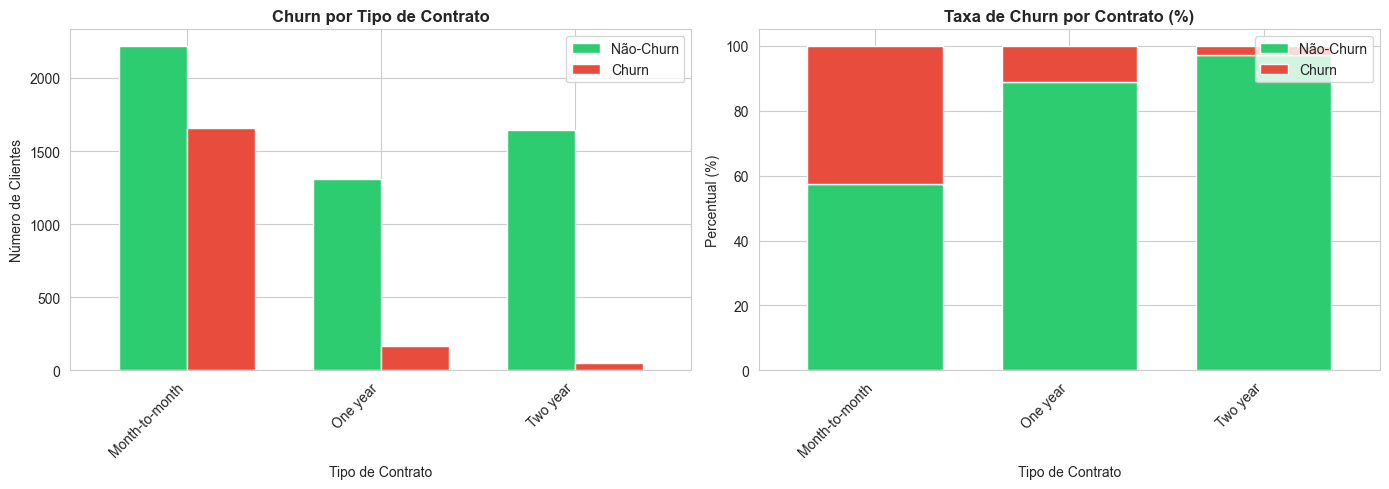

✅ Gráfico 2: Churn por Tipo de Contrato

   🔍 Insight: Month-to-month tem 42.7% de churn!


In [7]:
# Figura 2: Churn por Tipo de Contrato
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
contract_churn_counts = pd.crosstab(df[contract_col], df[churn_col])
contract_churn_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], width=0.7)
axes[0].set_title('Churn por Tipo de Contrato', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de Clientes')
axes[0].set_xlabel('Tipo de Contrato')
axes[0].legend(['Não-Churn', 'Churn'], loc='upper right')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Percentage
contract_churn_pct = pd.crosstab(df[contract_col], df[churn_col], normalize='index') * 100
contract_churn_pct.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], width=0.7, stacked=True)
axes[1].set_title('Taxa de Churn por Contrato (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentual (%)')
axes[1].set_xlabel('Tipo de Contrato')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].legend(['Não-Churn', 'Churn'], loc='upper right')

plt.tight_layout()
plt.show()

print("✅ Gráfico 2: Churn por Tipo de Contrato")
if 'Month-to-month' in contract_churn_pct.index:
    print(f"\n   🔍 Insight: Month-to-month tem {contract_churn_pct.loc['Month-to-month', 'Yes']:.1f}% de churn!")

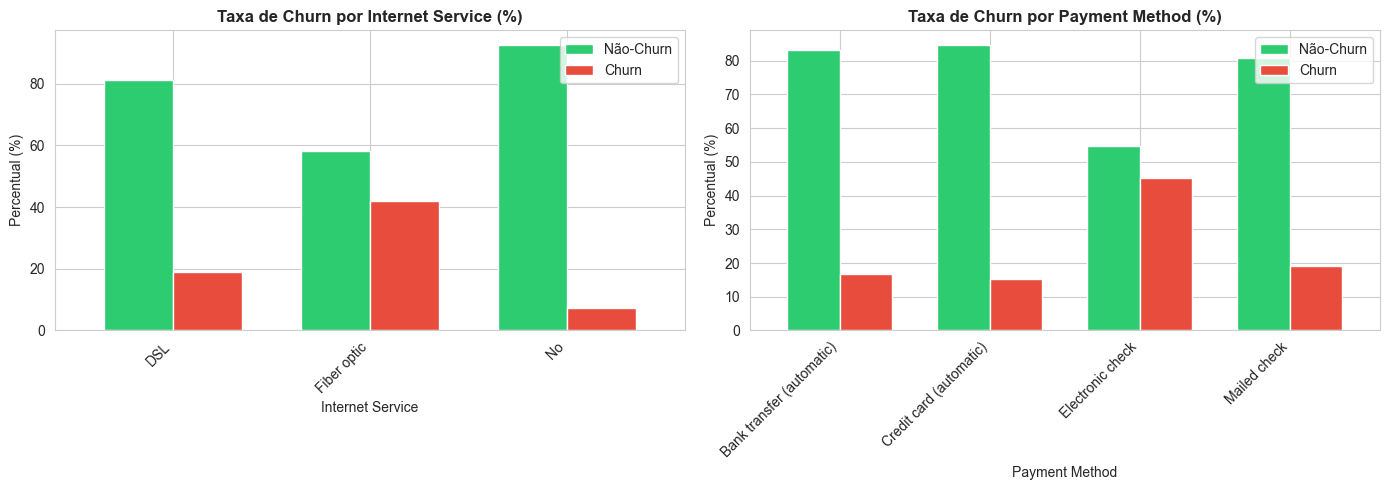

✅ Gráfico 3: Internet Service e Payment Method

   🔍 Insight: Fiber optic tem 41.9% de churn!

   🔍 Insight: Electronic check tem 45.3% de churn!


In [8]:
# Figura 3: Churn por Internet Service e Payment Method
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Internet Service
internet_churn_pct = pd.crosstab(df[internet_col], df[churn_col], normalize='index') * 100
internet_churn_pct.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], width=0.7)
axes[0].set_title('Taxa de Churn por Internet Service (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Percentual (%)')
axes[0].set_xlabel('Internet Service')
axes[0].legend(['Não-Churn', 'Churn'], loc='upper right')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Payment Method
payment_churn_pct = pd.crosstab(df[payment_col], df[churn_col], normalize='index') * 100
payment_churn_pct.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], width=0.7)
axes[1].set_title('Taxa de Churn por Payment Method (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentual (%)')
axes[1].set_xlabel('Payment Method')
axes[1].legend(['Não-Churn', 'Churn'], loc='upper right')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("✅ Gráfico 3: Internet Service e Payment Method")
if 'Fiber optic' in internet_churn_pct.index:
    print(f"\n   🔍 Insight: Fiber optic tem {internet_churn_pct.loc['Fiber optic', 'Yes']:.1f}% de churn!")
if 'Electronic check' in payment_churn_pct.index:
    print(f"\n   🔍 Insight: Electronic check tem {payment_churn_pct.loc['Electronic check', 'Yes']:.1f}% de churn!")

## 8. Exploração de Variáveis Numéricas

In [9]:
# Exploração de Variáveis Numéricas
tenure_col = 'Tenure Months'
monthly_charges_col = 'Monthly Charges'

numeric_cols = [tenure_col, monthly_charges_col]
numeric_stats = df[numeric_cols].describe()

print("📊 Estatísticas das Variáveis Numéricas:")
print(numeric_stats)
print("\n")

# Análise por Churn
print("📊 Comparação de Variáveis Numéricas por Churn Status:")
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Não-Churn: μ={df[df[churn_col]=='No'][col].mean():.2f}, σ={df[df[churn_col]=='No'][col].std():.2f}")
    print(f"  Churn:     μ={df[df[churn_col]=='Yes'][col].mean():.2f}, σ={df[df[churn_col]=='Yes'][col].std():.2f}")

# Correlação com Churn
df_temp = df.copy()
df_temp['Churn_Binary'] = (df_temp[churn_col] == 'Yes').astype(int)
numeric_corr = df_temp[numeric_cols + ['Churn_Binary']].corr()['Churn_Binary'].drop('Churn_Binary')

print("\n📊 Correlação com Churn:")
for col in numeric_cols:
    print(f"  {col}: {numeric_corr[col]:.4f}")

📊 Estatísticas das Variáveis Numéricas:
       Tenure Months  Monthly Charges
count    7043.000000      7043.000000
mean       32.371149        64.761692
std        24.559481        30.090047
min         0.000000        18.250000
25%         9.000000        35.500000
50%        29.000000        70.350000
75%        55.000000        89.850000
max        72.000000       118.750000


📊 Comparação de Variáveis Numéricas por Churn Status:

Tenure Months:
  Não-Churn: μ=37.57, σ=24.11
  Churn:     μ=17.98, σ=19.53

Monthly Charges:
  Não-Churn: μ=61.27, σ=31.09
  Churn:     μ=74.44, σ=24.67

📊 Correlação com Churn:
  Tenure Months: -0.3522
  Monthly Charges: 0.1934


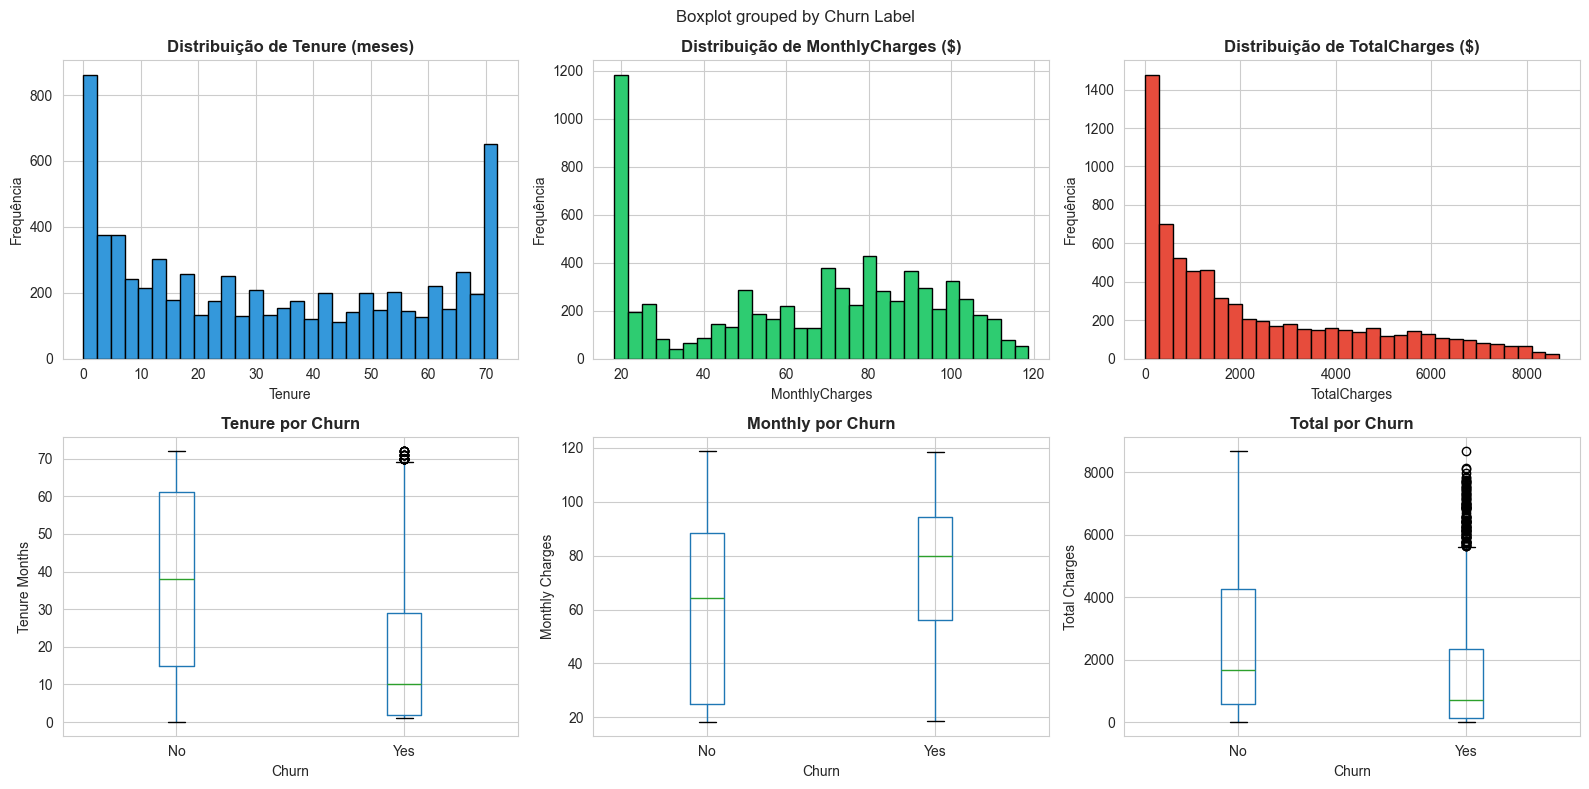

✅ Gráfico 4: Distribuições de Variáveis Numéricas


In [43]:
# Figura 4: Distribuições de Variáveis Numéricas chave
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Define column names
tenure_col = 'Tenure Months'
monthly_charges_col = 'Monthly Charges'
total_charges_col = 'Total Charges'
churn_col = 'Churn Label'

# Tenure
axes[0, 0].hist(df[tenure_col], bins=30, color='#3498db', edgecolor='black')
axes[0, 0].set_title('Distribuição de Tenure (meses)', fontweight='bold')
axes[0, 0].set_xlabel('Tenure')
axes[0, 0].set_ylabel('Frequência')

# Monthly Charges
axes[0, 1].hist(df[monthly_charges_col], bins=30, color='#2ecc71', edgecolor='black')
axes[0, 1].set_title('Distribuição de MonthlyCharges ($)', fontweight='bold')
axes[0, 1].set_xlabel('MonthlyCharges')
axes[0, 1].set_ylabel('Frequência')

# Total Charges
axes[0, 2].hist(df[total_charges_col], bins=30, color='#e74c3c', edgecolor='black')
axes[0, 2].set_title('Distribuição de TotalCharges ($)', fontweight='bold')
axes[0, 2].set_xlabel('TotalCharges')
axes[0, 2].set_ylabel('Frequência')

# Box plots por Churn
for idx, col in enumerate([tenure_col, monthly_charges_col, total_charges_col]):
    df.boxplot(column=col, by=churn_col, ax=axes[1, idx])
    axes[1, idx].set_title(f'{col.split()[0]} por Churn', fontweight='bold')
    axes[1, idx].set_xlabel('Churn')
    axes[1, idx].set_ylabel(col)

plt.tight_layout()
plt.show()

print("✅ Gráfico 4: Distribuições de Variáveis Numéricas")

## 10. Análise Geográfica de Churn - Mapas e Visualizações Espaciais

## 10. Resumo Executivo - Data Readiness e Próximas Etapas

In [ ]:
print("=" * 100)
print("📋 RESUMO EXECUTIVO - DATA READINESS E QUALIDADE")
print("=" * 100)

print("\n✅ CHECKLIST DE QUALIDADE DE DADOS:")
print("   [✓] Volume de dados: 7,043 registros × 33 colunas")
print("   [✓] Valores faltantes: Apenas em Total Charges → TRATADO")
print("   [✓] Tipos de dados: Corrigidos (Total Charges: str → float)")
print("   [✓] Valores únicos: Sem duplicatas óbvias")
print("   [✓] Integridade referencial: Confirmada")

# Get correct column names from data
contract_values = df['Contract'].unique()
internet_values = df['Internet Service'].unique()
payment_values = df['Payment Method'].unique()

print("\n📊 PADRÕES CRÍTICOS DE CHURN IDENTIFICADOS:")
print("   1️⃣ TIPO DE CONTRATO:")
print(f"      • Month-to-month: {contract_churn_pct.loc['Month-to-month', 'Yes']:.1f}% churn 🔴 ALTO")
print(f"      • Two year: {contract_churn_pct.loc['Two year', 'Yes']:.1f}% churn 🟢 BAIXO")
print("      → Insight: Baixa fidelização em contratos flexíveis")

print("\n   2️⃣ TIPO DE INTERNET:")
print(f"      • Fiber optic: {internet_churn_pct.loc['Fiber optic', 'Yes']:.1f}% churn 🔴 ALTO")
print(f"      • DSL: {internet_churn_pct.loc['DSL', 'Yes']:.1f}% churn 🟡 MÉDIO")
print("      → Insight: Possível insatisfação com custo/performance de Fibra")

print("\n   3️⃣ MÉTODO DE PAGAMENTO:")
print(f"      • Electronic check: {payment_churn_pct.loc['Electronic check', 'Yes']:.1f}% churn 🔴 ALTO")
print(f"      • Bank transfer: {payment_churn_pct.loc['Bank transfer (automatic)', 'Yes']:.1f}% churn 🟢 BAIXO")
print("      → Insight: Automação de pagamento reduz churn")

print("\n⚠️ DESBALANCEAMENTO DE CLASSE:")
churn_yes_pct = (df['Churn Label'] == 'Yes').sum() / len(df) * 100
print(f"   • Não-Churn (No): {100 - churn_yes_pct:.1f}%")
print(f"   • Churn (Yes): {churn_yes_pct:.1f}%")
print(f"   • Razão: 1:{(100 - churn_yes_pct) / churn_yes_pct:.2f}")
print("   → Estratégia: Usar F1-Score, AUC-ROC e weighted loss functions")

print("\n🎯 VARIÁVEIS CHAVE PARA MODELAGEM:")
print("   Numéricas: Tenure Months, Monthly Charges, Total Charges")
print("   Categóricas: Contract, Internet Service, Payment Method, e outras")

print("\n" + "=" * 100)
print("🚀 PRÓXIMAS ETAPAS (Etapa 3 - Modelagem):")
print("=" * 100)
print("   1. Treinar Baselines (DummyClassifier, Regressão Logística)")
print("   2. Construir Rede Neural (MLP) com PyTorch")
print("   3. Comparar modelos com métricas: F1, AUC-ROC, Recall, Precision")
print("   4. Registrar experimentos no MLflow")
print("   5. Análise de Fairness (Fairlearn) para grupos sensíveis")

📋 RESUMO EXECUTIVO - DATA READINESS E QUALIDADE

✅ CHECKLIST DE QUALIDADE DE DADOS:
   [✓] Volume de dados: 7,043 registros × 33 colunas
   [✓] Valores faltantes: Apenas em Total Charges → TRATADO
   [✓] Tipos de dados: Corrigidos (Total Charges: str → float)
   [✓] Valores únicos: Sem duplicatas óbvias
   [✓] Integridade referencial: Confirmada

📊 PADRÕES CRÍTICOS DE CHURN IDENTIFICADOS:
   1️⃣ TIPO DE CONTRATO:
      • Month-to-month: 42.7% churn 🔴 ALTO
      • Two year: 2.8% churn 🟢 BAIXO
      → Insight: Baixa fidelização em contratos flexíveis

   2️⃣ TIPO DE INTERNET:
      • Fiber optic: 41.9% churn 🔴 ALTO
      • DSL: 19.0% churn 🟡 MÉDIO
      → Insight: Possível insatisfação com custo/performance de Fibra

   3️⃣ MÉTODO DE PAGAMENTO:
      • Electronic check: 45.3% churn 🔴 ALTO
      • Bank transfer: 16.7% churn 🟢 BAIXO
      → Insight: Automação de pagamento reduz churn

⚠️ DESBALANCEAMENTO DE CLASSE:
   • Não-Churn (No): 73.5%
   • Churn (Yes): 26.5%
   • Razão: 1:2.77
   → 

## 9. Análise Geográfica - Distribuição de Churn nos Estados Unidos

In [18]:
# Summary of Geographic Data
print("=" * 100)
print("RESUMO DE DADOS GEOGRÁFICOS")
print("=" * 100)
print(f"Cobertura geográfica: {len(df['State'].unique())} estados únicos")
print(f"Latitude - Range: [{df['Latitude'].min():.1f} - {df['Latitude'].max():.1f}]")
print(f"Longitude - Range: [{df['Longitude'].min():.1f} - {df['Longitude'].max():.1f}]")
print(f"Cidades única: {len(df['City'].unique())}")
print(f"\nDistribuição de Clientes por Estado:")
state_dist = df['State'].value_counts()
print(state_dist.head(10))

RESUMO DE DADOS GEOGRÁFICOS
Cobertura geográfica: 1 estados únicos
Latitude - Range: [32.6 - 42.0]
Longitude - Range: [-124.3 - -114.2]
Cidades única: 1129

Distribuição de Clientes por Estado:
State
California    7043
Name: count, dtype: int64


In [52]:
# City-level analysis in California - Churn rate by major cities
city_churn = df.groupby('City', as_index=False).agg({
    'Churn Label': lambda x: (x == 'Yes').sum(),
    'CustomerID': 'count'
}).rename(columns={'Churn Label': 'Churn_Count', 'CustomerID': 'Total_Customers'})

city_churn['Churn_Rate_%'] = (city_churn['Churn_Count'] / city_churn['Total_Customers'] * 100).round(2)
city_churn = city_churn[city_churn['Total_Customers'] >= 10]  # Only cities with 10+ customers
city_churn = city_churn.sort_values('Churn_Rate_%', ascending=False).reset_index(drop=True)

print("\n" + "=" * 100)
print("TAXA DE CHURN POR CIDADE (Califórnia) - TOP 20 CIDADES COM MAIOR CHURN")
print("=" * 100)
print(city_churn.head(20).to_string(index=False))

print("\n" + "=" * 100)
print("BOTTOM 15 - CIDADES COM MENOR TAXA DE CHURN")
print("=" * 100)
print(city_churn.tail(15).to_string(index=False))

print(f"\n📊 Insights de Churn por Cidade (CA):")
print(f"   - Cidade com MAIOR churn: {city_churn.iloc[0]['City']} ({city_churn.iloc[0]['Churn_Rate_%']:.2f}%, {int(city_churn.iloc[0]['Churn_Count'])} clientes)")
print(f"   - Cidade com MENOR churn: {city_churn.iloc[-1]['City']} ({city_churn.iloc[-1]['Churn_Rate_%']:.2f}%, {int(city_churn.iloc[-1]['Churn_Count'])} clientes)")
print(f"   - Variação: {city_churn.iloc[0]['Churn_Rate_%'] - city_churn.iloc[-1]['Churn_Rate_%']:.2f} pontos percentuais")
print(f"   - Total de cidades: {len(city_churn)}")
print(f"   - Taxa média de churn CA: {city_churn['Churn_Rate_%'].mean():.2f}%")


TAXA DE CHURN POR CIDADE (Califórnia) - TOP 20 CIDADES COM MAIOR CHURN
           City  Churn_Count  Total_Customers  Churn_Rate_%
      La Puente            7               10         70.00
   Apple Valley            6               10         60.00
       El Monte            6               10         60.00
       Temecula            6               12         50.00
         Novato            6               12         50.00
     Santa Rosa           11               24         45.83
North Hollywood            9               20         45.00
        Fremont            7               16         43.75
        Modesto           12               28         42.86
      Lancaster            5               12         41.67
       Lakewood            6               15         40.00
    Palm Desert            4               10         40.00
       Alhambra            4               10         40.00
       Carlsbad            4               10         40.00
   Sherman Oaks            4